In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file_name = list(uploaded.keys())[0]

extract_path = "/content/stock_dataset"

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

In [2]:
csv_files = {}

for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        if file.endswith(".csv"):

            stock_name = file.replace(".csv", "").upper()

            full_path = os.path.join(root, file)

            csv_files[stock_name] = full_path

print("Total CSV files found:", len(csv_files))

NameError: name 'os' is not defined

In [1]:
search = input("Enter stock name or symbol: ").upper()

matches = [name for name in csv_files.keys() if search in name]

print("Matching stocks:\n")

for name in matches[:30]:
    print(name)

Enter stock name or symbol: AAMC


NameError: name 'csv_files' is not defined

In [ ]:
selected_stock = input("Enter exact stock name: ").upper()

selected_file = csv_files[selected_stock]

print("Selected file path:")
print(selected_file)

Enter exact stock name: BNO
Selected file path:
/content/stock_dataset/archive/etfs/BNO.csv


In [ ]:
import pandas as pd

df = pd.read_csv(selected_file)

df.columns = df.columns.str.strip()

print(df.head())

         Date       Open       High        Low      Close  Adj Close  Volume
0  2010-06-02  25.485001  25.615000  25.320000  25.590000  25.590000   26800
1  2010-06-03  25.715000  25.915001  25.420000  25.830000  25.830000   66800
2  2010-06-04  25.245001  25.245001  24.670000  24.700001  24.700001   12000
3  2010-06-07  24.799999  24.985001  24.565001  24.795000  24.795000   29000
4  2010-06-08  24.695000  24.850000  24.594999  24.690001  24.690001   65400


In [ ]:
df.columns = df.columns.str.strip()

print(df.columns)
print(df.head())
print(df.info())

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
         Date       Open       High        Low      Close  Adj Close  Volume
0  2010-06-02  25.485001  25.615000  25.320000  25.590000  25.590000   26800
1  2010-06-03  25.715000  25.915001  25.420000  25.830000  25.830000   66800
2  2010-06-04  25.245001  25.245001  24.670000  24.700001  24.700001   12000
3  2010-06-07  24.799999  24.985001  24.565001  24.795000  24.795000   29000
4  2010-06-08  24.695000  24.850000  24.594999  24.690001  24.690001   65400
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2476 entries, 0 to 2475
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2476 non-null   object 
 1   Open       2476 non-null   float64
 2   High       2476 non-null   float64
 3   Low        2476 non-null   float64
 4   Close      2476 non-null   float64
 5   Adj Close  2476 non-null   float64
 6   Volume     2476 non-

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
df = df.dropna()

df.head()

,Date,Open,High,Low,Close,Volume
0,2010-06-02,25.485001,25.615000,25.320000,25.590000,26800
1,2010-06-03,25.715000,25.915001,25.420000,25.830000,66800
2,2010-06-04,25.245001,25.245001,24.670000,24.700001,12000
3,2010-06-07,24.799999,24.985001,24.565001,24.795000,29000
4,2010-06-08,24.695000,24.850000,24.594999,24.690001,65400


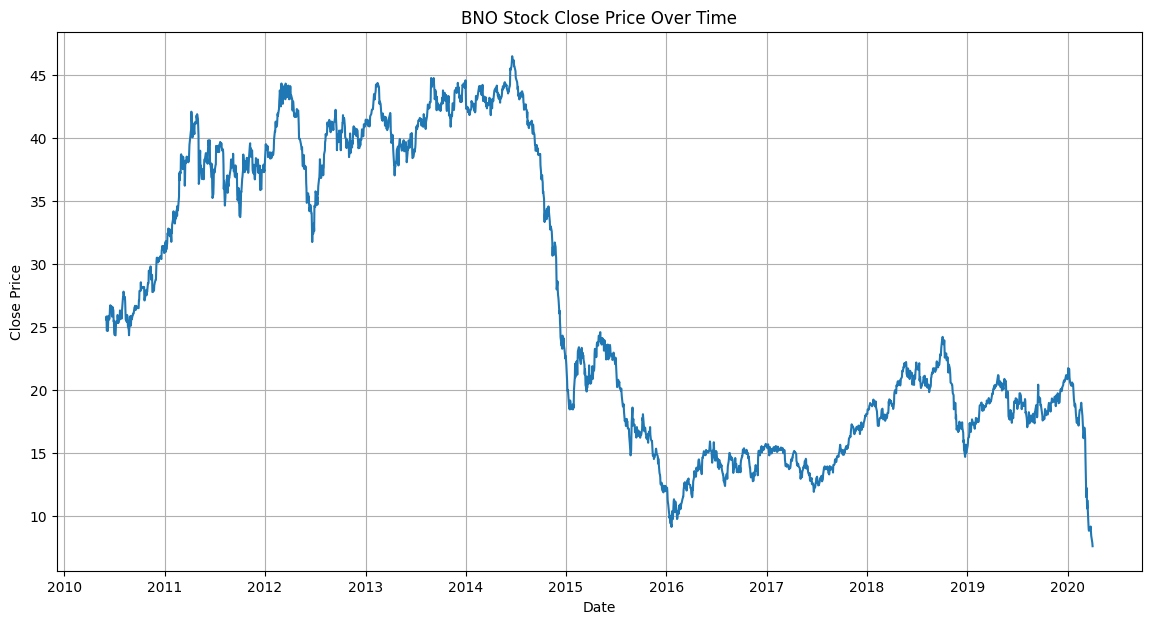

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Close', data=df)
plt.title(f'{selected_stock} Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [ ]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
target = 'Close'

data = df[features].values

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [ ]:
sequence_length = 90

X = []
y = []

target_index = features.index('Close')

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, target_index])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2386, 90, 5)
y shape: (2386,)


In [ ]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1908, 90, 5)
Testing data: (478, 90, 5)


In [ ]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 90, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - loss: 0.0345 - val_loss: 1.6662e-04
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0056 - val_loss: 3.3182e-04
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0045 - val_loss: 1.9617e-04
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0036 - val_loss: 1.4112e-04
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0035 - val_loss: 3.1675e-04
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - loss: 0.0029 - val_loss: 1.5458e-04
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 0.0029 - val_loss: 1.4003e-04
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0031 - val_loss: 1.7133e-04
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0025 - val_loss: 1.9143e-04
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0024 - val_loss: 1.3546e-04
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0024 - val_loss: 3.3371e-04
Epoch 12/50
54/54

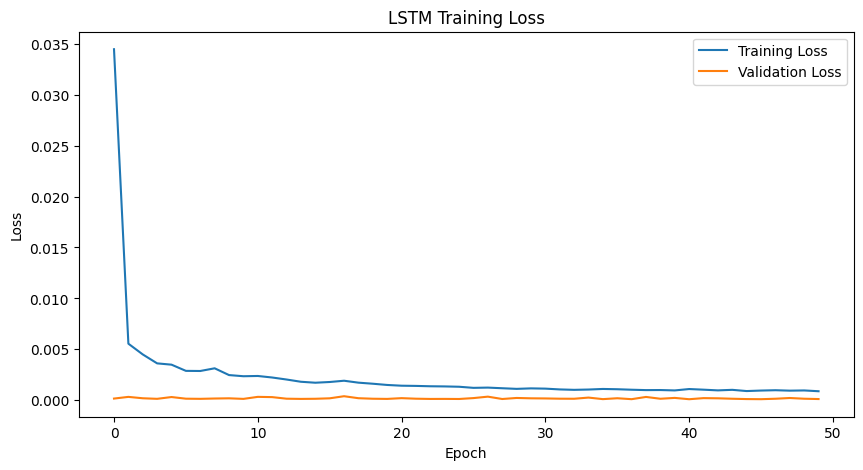

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
predicted_scaled = model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


In [ ]:
dummy_pred = np.zeros((len(predicted_scaled), len(features)))
dummy_test = np.zeros((len(y_test), len(features)))

dummy_pred[:, target_index] = predicted_scaled[:, 0]
dummy_test[:, target_index] = y_test

predicted_prices = scaler.inverse_transform(dummy_pred)[:, target_index]
actual_prices = scaler.inverse_transform(dummy_test)[:, target_index]

In [ ]:
mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
r2 = r2_score(actual_prices, predicted_prices)

print("Model Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Performance:
MAE: 0.7727963153122558
RMSE: 1.0398929369677485
R² Score: 0.8398169863368212


In [ ]:
accuracy_percentage = r2 * 100
print(f"Model Accuracy based on R² Score: {accuracy_percentage:.2f}%")

Model Accuracy based on R² Score: 83.98%


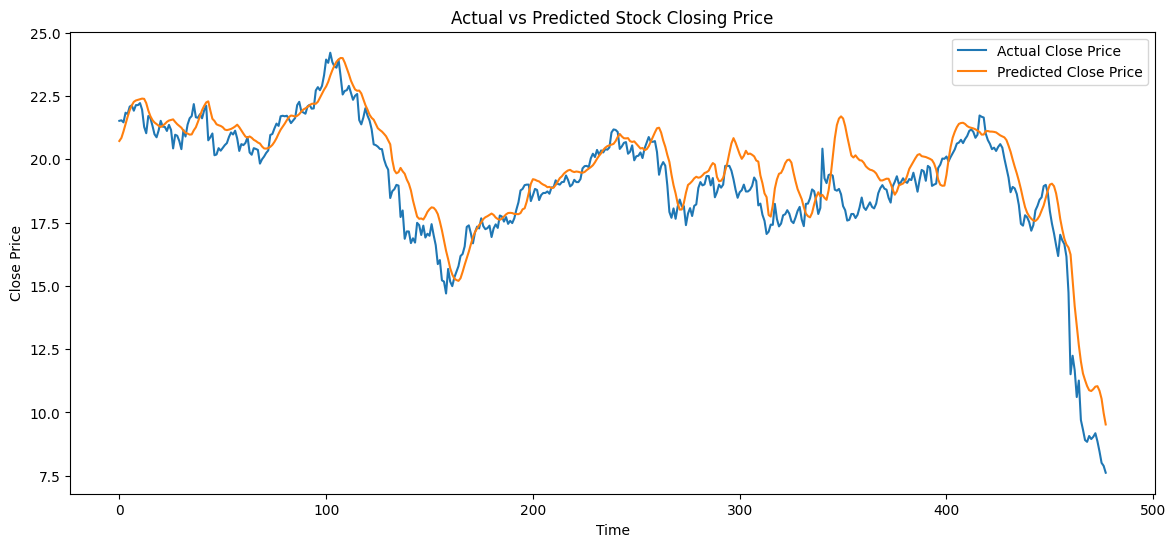

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(actual_prices, label='Actual Close Price')
plt.plot(predicted_prices, label='Predicted Close Price')
plt.title('Actual vs Predicted Stock Closing Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [ ]:
last_60_days = scaled_data[-sequence_length:]

last_60_days = np.array(last_60_days)
last_60_days = np.reshape(last_60_days, (1, sequence_length, len(features)))

next_day_scaled = model.predict(last_60_days)

dummy_next = np.zeros((1, len(features)))
dummy_next[:, target_index] = next_day_scaled[0][0]

next_day_price = scaler.inverse_transform(dummy_next)[:, target_index]

print("Predicted Next Day Close Price:", next_day_price[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Next Day Close Price: 8.987620179858737


In [ ]:
new_uploaded = files.upload()

new_file_name = list(new_uploaded.keys())[0]
new_df = pd.read_csv(new_file_name)

new_df.columns = new_df.columns.str.strip()
new_df['Date'] = pd.to_datetime(new_df['Date'])
new_df = new_df.sort_values('Date')

new_df = new_df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
new_df = new_df.dropna()

new_df.head()

Saving BON_Test.csv to BON_Test (1).csv


,Date,Open,High,Low,Close,Volume
0,2022-10-14,18.610000,18.710000,18.409999,18.630000,954000
1,2022-10-15,18.589999,18.760000,18.440000,18.530000,649700
2,2022-10-16,18.450000,18.780000,18.450000,18.680000,605600
3,2022-10-17,18.579999,18.850000,18.460000,18.829999,471200
4,2022-10-18,18.850000,18.890001,18.570001,18.650001,506300


In [ ]:
new_data = new_df[features].values

new_scaled_data = scaler.transform(new_data)

last_60_new = new_scaled_data[-sequence_length:]

last_60_new = np.array(last_60_new)
last_60_new = np.reshape(last_60_new, (1, sequence_length, len(features)))

new_prediction_scaled = model.predict(last_60_new)

dummy_new = np.zeros((1, len(features)))
dummy_new[:, target_index] = new_prediction_scaled[0][0]

new_predicted_price = scaler.inverse_transform(dummy_new)[:, target_index]

print("Forecasted Next Day Close Price:", new_predicted_price[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Forecasted Next Day Close Price: 9.49586089960438
